# Differential gene expression across condition combinations

In clinical data analysis, we often need to run differential expression (DE)
across combinations of covariates: for example, comparing COVID-19 patients
to healthy volunteers *within each sex group* to understand whether the
transcriptional response to disease differs between men and women.

`patpy` makes this easy with `ptc.ConditionComparison`. It handles:
- creating a combined condition label column
- enumerating all (or a selected subset of) observed pairwise contrasts
- running `model.compare_groups()` for each pair
- concatenating results with a `"contrast"` column
- storing a fitted model instance per contrast for pertpy's plotting API

We use the **COMBAT COVID-19 cohort** (PBMC from ~140 donors) as a real-world
example, following the same pseudobulk pipeline as the
[pertpy DE tutorial](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html).

## Install

```bash
pip install patpy pertpy pydeseq2
# For EdgeR (requires R):
pip install rpy2
# In R: BiocManager::install("edgeR")
```

## Import packages

In [1]:
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import warnings

import patpy
import patpy.tl.condition_comparison as ptc

warnings.filterwarnings("ignore")
patpy.__version__

/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_patpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.12.1'

## Load the COMBAT dataset

The dataset contains 836k cells x 20,807 genes from ~140 PBMC donors spanning
healthy volunteers (HV) and COVID-19 patients at various severity levels.

In [2]:
ADATA_PATH = "/home/icb/lucas.arnoldt/workspace/projects/patpy/COMBAT-CITESeq-DATA.h5ad"
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 836148 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_H

## Set column names

In [3]:
sample_id_col = "scRNASeq_sample_ID"       # per-donor identifier
cell_type_key = "Annotation_major_subset"  # broad cell type labels
source_col    = "Source"                   # COVID_SEV / HV
sex_col       = "Sex"                      # 0 = male, 1 = female

## Quality control

Remove donors with fewer than 100 cells.

In [4]:
adata = patpy.pp.filter_small_samples(
    adata, sample_key=sample_id_col, sample_size_threshold=100
)
print(f"{adata.obs[sample_id_col].nunique()} donors after QC filtering")
adata.layers["raw"] = adata.layers["raw"].todense()

2 samples removed: G05092-Ja005E-PBCa, S00030-Ja003E-PBCa
138 donors after QC filtering


## Subset to a manageable cohort

We keep only **COVID-19 patients and healthy volunteers** and sample up to
**20 donors per source** so the analysis finishes quickly.
Remove this cell to run on the full dataset.

In [5]:
# Restrict to Covid and HV sources only
adata = adata[adata.obs[source_col].isin(["COVID_SEV", "HV"])].copy()

# Recode Sex to readable labels
adata.obs[sex_col] = adata.obs[sex_col].map({0: "male", 1: "female"})

# Sample up to 20 donors per source so both groups are always present
rng = np.random.default_rng(42)
keep = []
for source, grp in adata.obs.groupby(source_col):
    donors = grp[sample_id_col].unique()
    sampled = rng.choice(donors, size=min(20, len(donors)), replace=False)
    keep.extend(sampled)

adata = adata[adata.obs[sample_id_col].isin(keep)].copy()

print(f"{adata.n_obs:,} cells | {adata.obs[sample_id_col].nunique()} donors")
adata.obs[[sample_id_col, source_col]].drop_duplicates()[source_col].value_counts()

214,842 cells | 30 donors


Source
COVID_SEV    20
HV           10
Name: count, dtype: int64

## Create pseudobulk profiles

DE models require integer counts aggregated at the donor level.
We use `patpy.tl.Pseudobulk` for aggregation and `patpy.pp.extract_metadata`
to build the donor-level obs DataFrame.

In [6]:
pb = patpy.tl.Pseudobulk(
    sample_key=sample_id_col,
    cell_group_key=cell_type_key,
    layer="raw",
)
pb.prepare_anndata(adata)
pb.calculate_distance_matrix(aggregate="sum")
print(f"sample_representation shape: {pb.sample_representation.shape}")
print(f"donors: {len(pb.samples)}")

sample_representation shape: (30, 20807)
donors: 30


In [7]:
# Build donor-level obs using patpy.pp.extract_metadata
donor_obs = patpy.pp.extract_metadata(
    adata, sample_key=sample_id_col, columns=[source_col, sex_col]
)
donor_obs

,Source,Sex
scRNASeq_sample_ID,,
S00056-Ja003E-PBCa,COVID_SEV,male
H00067-Ha001E-PBGa,HV,male
S00028-Ja001E-PBCa,COVID_SEV,male
S00033-Ja001E-PBCa,COVID_SEV,female
H00054-Ha001E-PBGa,HV,female
S00078-Ja003E-PBCa,COVID_SEV,male
S00042-Ja003E-PBCa,COVID_SEV,male
H00085-Ha001E-PBGa,HV,male
S00056-Ja005E-PBCa,COVID_SEV,male


In [8]:
pdata = pb.to_adata(metadata=donor_obs)
pdata.var = adata.var

## Explore axes of variation

Before fitting any DE model it is useful to understand which covariates
drive variance in the pseudobulk profiles. We run PCA and use
`patpy.tl.associate_embedding_with_covariates` to test each PC against each
clinical variable, then visualise with `patpy.pl.embedding_covariate_heatmap`.

This guides the choice of design formula and which contrasts are worth testing.

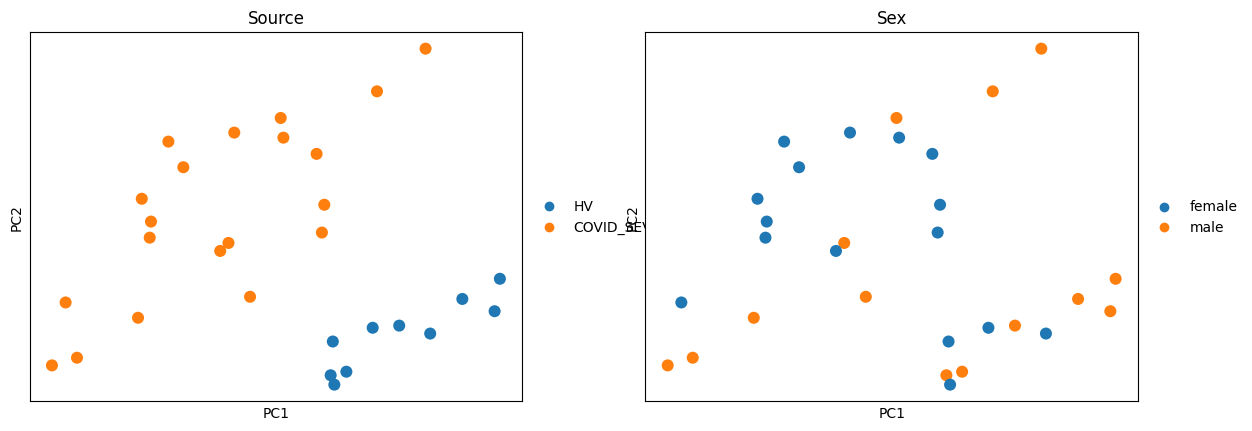

In [9]:
pdata_pca = pdata.copy()
sc.pp.normalize_total(pdata_pca, target_sum=1e4)
sc.pp.log1p(pdata_pca)
sc.pp.scale(pdata_pca, max_value=10)
sc.pp.pca(pdata_pca)

# Copy PCA embedding back to pdata for downstream association test
pdata.obsm["X_pca"] = pdata_pca.obsm["X_pca"]

sc.pl.pca(pdata_pca, color=[source_col, sex_col], ncols=2, size=300)

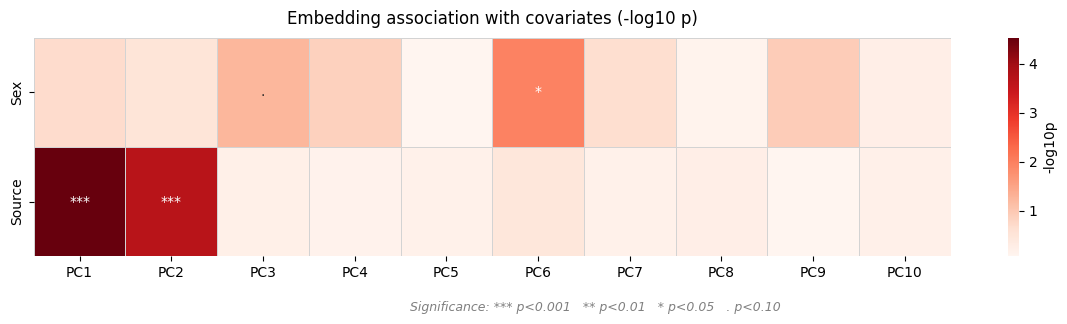

In [10]:
# Test which PCs are driven by each clinical covariate
assoc = patpy.tl.associate_embedding_with_covariates(
    pdata,
    covariates=[source_col, sex_col],
    obsm_key="X_pca",
    n_components=10,
)

patpy.pl.embedding_covariate_heatmap(assoc)

## Inspect the condition space

`ptc.build_condition_combinations` lists every *observed* combination of
condition axes and `ptc.build_all_pairwise_contrasts` enumerates all pairs.
This is a quick sanity check before launching any model fits.

In [11]:
condition_cols = [source_col, sex_col]

combos = ptc.build_condition_combinations(pdata, condition_cols)
print(f"{len(combos)} observed condition combinations:")
combos

4 observed condition combinations:


,Source,Sex,label
0,COVID_SEV,male,COVID_SEV_male
1,HV,male,HV_male
2,COVID_SEV,female,COVID_SEV_female
3,HV,female,HV_female


In [12]:
contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)
print(f"{len(contrasts)} pairwise contrasts:")
for c in contrasts:
    print(f"  {c['label']}")

6 pairwise contrasts:
  COVID_SEV_male_vs_HV_male
  COVID_SEV_male_vs_COVID_SEV_female
  COVID_SEV_male_vs_HV_female
  HV_male_vs_COVID_SEV_female
  HV_male_vs_HV_female
  COVID_SEV_female_vs_HV_female


## Differential expression — PyDESeq2

In clinical data analysis, we often need to run DE for a combination of
covariates. `patpy` makes this easy with `ptc.ConditionComparison`. Let's use
it to explore how the COVID-19 transcriptional response interacts with the sex
of patients.

`run_once` returns a `(results_df, models)` tuple. `results_df` is the tidy
DE table with a `"contrast"` column; `models` is a dict mapping each contrast
label to a model instance for pertpy's plotting API.

In [13]:
res_deseq2, models_deseq2 = ptc.ConditionComparison.run_once(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
)

print(f"{len(res_deseq2):,} DE results across {res_deseq2['contrast'].nunique()} contrasts")
print("Available contrasts:", list(models_deseq2))
res_deseq2.head()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.09 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 1.45 seconds.

Fitting LFCs...
... done in 1.08 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Running Wald tests...
... done in 42.43 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting dispersions...
... done in 1.05 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 1.42 seconds.

Fitting LFCs...
... done in 1.01 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 161 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Running Wald tests...
... done in 10.25 seconds.

Fitting size factors...
... done in 0.01 seconds.



...

Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218150  3.429169 -0.063616  0.949276   
NOC2L             1457.437279        0.008025  0.072268  0.111045  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898299  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114996 -1.119209  0.263051   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787390  0.073875   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949  0

Fitting dispersions...
... done in 1.02 seconds.

Fitting dispersion trend curve...
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 0.93 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

... done in 10.33 seconds.



,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,ZNF230,138.987101,-1.575528,0.147200,-10.703326,9.818907e-27,1.443870e-22,COVID_SEV_male_vs_HV_male
1,TNFSF14,328.762813,-1.947968,0.184911,-10.534641,5.981085e-26,4.397593e-22,COVID_SEV_male_vs_HV_male
2,CDCA5,236.643742,3.006126,0.309581,9.710300,2.725329e-22,1.335865e-18,COVID_SEV_male_vs_HV_male
3,METTL18,399.540801,-1.138663,0.118743,-9.589296,8.868817e-22,3.260399e-18,COVID_SEV_male_vs_HV_male
4,ID3,546.295056,-2.568833,0.269282,-9.539555,1.434469e-21,4.218774e-18,COVID_SEV_male_vs_HV_male


## Differential expression - EdgeR

Switch to EdgeR by changing a single argument. Everything else is identical.
EdgeR requires R with the `edgeR` Bioconductor package installed.

In [14]:
res_edger, models_edger = ptc.ConditionComparison.run_once(
    pt.tl.EdgeR,
    pdata,
    condition_cols=condition_cols,
)

print(f"{len(res_edger):,} DE results across {res_edger['contrast'].nunique()} contrasts")
res_edger.head()

• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
124,842 DE results across 6 contrasts


,variable,log_fc,logCPM,F,p_value,adj_p_value,contrast
0,ZNF230,-1.597952,1.332414,118.189063,9.179426e-09,0.00010,COVID_SEV_male_vs_HV_male
1,TNFSF14,-1.966533,2.558231,117.450233,9.567627e-09,0.00010,COVID_SEV_male_vs_HV_male
2,KIRREL3,-3.524165,-2.683243,68.893660,1.792087e-08,0.00011,COVID_SEV_male_vs_HV_male
3,S1PR1,-1.521756,5.490698,102.687991,2.445235e-08,0.00011,COVID_SEV_male_vs_HV_male
4,ID3,-2.589889,3.292700,101.491364,2.654054e-08,0.00011,COVID_SEV_male_vs_HV_male


## Reuse settings with `ConditionComparison`

`ConditionComparison` stores the model class and default kwargs so you can
run the same setup across multiple condition axes without repeating yourself.
After each `run()` call, model instances are stored in `cc.models_` and
accessible via the named plot wrappers (`plot_volcano`, `plot_fold_change`,
`plot_multicomparison_fc`) or `cc.get_model(contrast_label)` for full control.

In [15]:
cc = ptc.ConditionComparison(pt.tl.PyDESeq2)
cc

ConditionComparison(PyDESeq2, )

In [16]:
# All pairwise combinations of Source x Sex
res_source_sex = cc.run(pdata, condition_cols=[source_col, sex_col])

# Source alone — the primary biological axis from the original COMBAT paper
res_source = cc.run(pdata, condition_cols=[source_col])

print("Source x Sex contrasts:", res_source_sex["contrast"].unique().tolist())
print("Source-only contrasts: ", res_source["contrast"].unique().tolist())
print("All stored models:", list(cc.models_))
cc  # repr shows model count after run

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.01 seconds.

Fitting dispersion trend curve...
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 1.31 seconds.

Fitting LFCs...
... done in 1.17 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Running Wald tests...
... done in 15.05 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting dispersions...
... done in 1.10 seconds.

Fitting dispersion trend curve...
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 1.39 seconds.

Fitting LFCs...
... done in 0.95 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 161 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Running Wald tests...
... done in 9.15 seconds.

Fitting size factors...
... done in 0.01 seconds.



...

Fitting dispersions...
... done in 1.18 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 1.39 seconds.

Fitting LFCs...
... done in 1.42 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Running Wald tests...
... done in 10.18 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

Fitting dispersions...
... done in 1.57 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 1.51 seconds.

Fitting LFCs...
... done in 2.02 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.10 seconds.

Running Wald tests...
... done in 30.24 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248338  1.305570  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120222  3.406467  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836254  0.403012   
AB_DR3_TRAMP     50528.479383       -0.093938  0.091834 -1.022908 

ConditionComparison(PyDESeq2, ) [7 model(s): ['COVID_SEV_male_vs_HV_male', 'COVID_SEV_male_vs_COVID_SEV_female', 'COVID_SEV_male_vs_HV_female', 'HV_male_vs_COVID_SEV_female', 'HV_male_vs_HV_female', 'COVID_SEV_female_vs_HV_female', 'COVID_SEV_vs_HV']]

## Restrict to biologically motivated contrasts

Pass `subset_contrasts` to run only the comparisons you care about — here,
only contrasts that involve the healthy volunteer (HV) reference group.
With readable sex labels and four condition groups (COVID_SEV_female,
COVID_SEV_male, HV_female, HV_male), this gives us five interpretable
disease-vs-healthy comparisons.

In [17]:
all_contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)

vs_hv = [c for c in all_contrasts if "HV" in c["group"] or "HV" in c["baseline"]]
print("Contrasts vs HV:", [c["label"] for c in vs_hv])

res_vs_hv, models_vs_hv = ptc.ConditionComparison.run_once(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
    subset_contrasts=vs_hv,
)
res_vs_hv["contrast"].unique()

Contrasts vs HV: ['COVID_SEV_male_vs_HV_male', 'COVID_SEV_male_vs_HV_female', 'HV_male_vs_COVID_SEV_female', 'HV_male_vs_HV_female', 'COVID_SEV_female_vs_HV_female']
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.22 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 1.18 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Running Wald tests...
... done in 24.21 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting dispersions...
... done in 1.23 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 1.28 seconds.

Fitting LFCs...
... done in 0.80 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 123 outlier genes.

Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...
... done in 19.08 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.304920        0.413179  2.795188  0.147818  0.882486   
NOC2L             1275.680812        0.094984  0.141383  0.671824  0.501696   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15661.234430       -0.046817  0.227499 -0.205790  0.836955   
AB_CD224        220335.647664        0.167137  0.180218  0.927415  0.353711   
AB_c_Met         44364.190769       -0.055211  0.201932 -0.273415  0.784534   
AB_CD258_LIGHT   31169.337939        0.077529  0.240061  0.322956  0.746729   
AB_DR3_TRAMP     54636.606110       -0.082354  0.184598 -0.446130 

...

Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218150  3.429169 -0.063616  0.949276   
NOC2L             1457.437279        0.008025  0.072268  0.111045  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898299  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114996 -1.119209  0.263051   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787390  0.073875   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949  0

Fitting dispersions...
... done in 1.02 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 1.32 seconds.

Fitting LFCs...
... done in 0.93 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

... done in 15.10 seconds.



array(['COVID_SEV_male_vs_HV_male', 'COVID_SEV_male_vs_HV_female',
       'HV_male_vs_COVID_SEV_female', 'HV_male_vs_HV_female',
       'COVID_SEV_female_vs_HV_female'], dtype=object)

## Inspect and visualise results

### How many genes are differentially expressed per contrast?

We first look at the number of DE genes (FDR < 0.05) per contrast to get
a sense of which comparisons are most informative.

In [18]:
# Number of significant genes per contrast (FDR < 0.05)
sig = res_deseq2[res_deseq2["adj_p_value"] < 0.05]
n_sig = (
    sig.groupby("contrast")["variable"]
    .count()
    .rename("n_sig_genes")
    .sort_values(ascending=False)
)
print(n_sig.to_string())

contrast
HV_male_vs_COVID_SEV_female           6316
COVID_SEV_female_vs_HV_female         4135
COVID_SEV_male_vs_HV_male             3641
COVID_SEV_male_vs_HV_female           2377
COVID_SEV_male_vs_COVID_SEV_female     231
HV_male_vs_HV_female                    70


The contrast with the most DE genes is `HV_male_vs_COVID_SEV_female`. This is expected: it conflates
two orthogonal biological signals (disease status *and* sex) so genes
driving both effects are captured simultaneously. The contrast with the
fewest DE genes (`HV_male_vs_HV_female`) reflects pure
sex differences in healthy individuals.

Most interesting are the within-sex disease comparisons
(`COVID_SEV_female_vs_HV_female` and `COVID_SEV_male_vs_HV_male`): comparing
their DE gene counts tells us whether the transcriptional response to COVID-19
is stronger in one sex than the other.

### Volcano plots: COVID-19 response within each sex

We visualise the two within-sex disease contrasts side-by-side. If the
response is sex-dimorphic, we expect different genes or different effect sizes
between the two plots.

NaNs encountered, dropping rows with NaNs


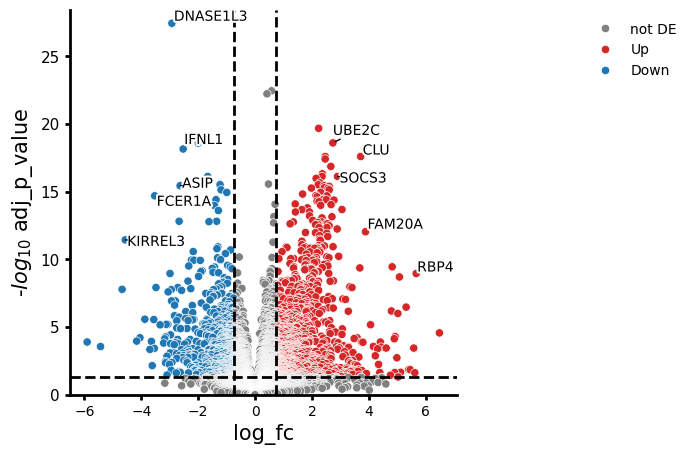

In [19]:
# COVID in females vs healthy females
cc.plot_volcano("COVID_SEV_female_vs_HV_female", results_df=res_source_sex)

NaNs encountered, dropping rows with NaNs


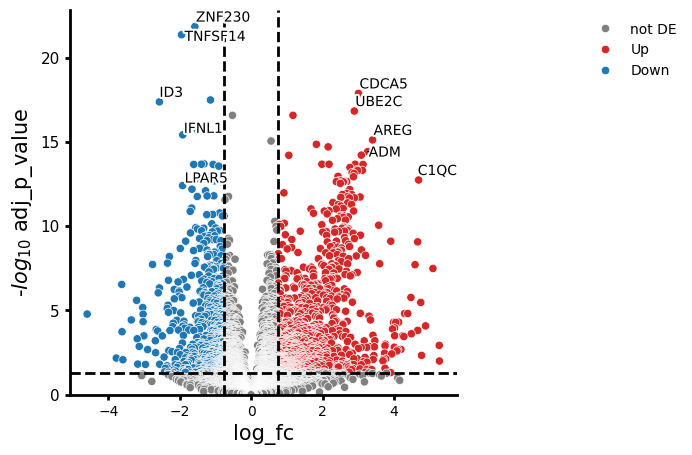

In [20]:
# COVID in males vs healthy males
cc.plot_volcano("COVID_SEV_male_vs_HV_male", results_df=res_source_sex)

Comparing the two volcano plots, we can see whether men or women show a
stronger or qualitatively different transcriptional response to severe
COVID-19. Top hits appearing in both contrasts represent a robust,
sex-independent COVID-19 signature; hits unique to one contrast suggest
sex-dimorphic regulation.

### Top DE genes across all contrasts

In [21]:
# Top DE genes across all contrasts (FDR < 0.05, ranked by |log2FC|)
(
    sig
    .assign(abs_lfc=sig["log_fc"].abs())
    .sort_values("abs_lfc", ascending=False)
    [["variable", "log_fc", "adj_p_value", "contrast"]]
    .drop_duplicates(subset="variable")
    .head(20)
)

,variable,log_fc,adj_p_value,contrast
62669,NLGN4Y,6.938495,9.139796e-13,HV_male_vs_COVID_SEV_female
104790,IGHV7-4-1,6.479591,2.700344e-05,COVID_SEV_female_vs_HV_female
41625,PPP1R2C,-6.109462,5.559397e-16,COVID_SEV_male_vs_HV_female
63686,IGHV2-70D,-6.057814,2.458839e-06,HV_male_vs_COVID_SEV_female
63105,MT1M,-5.979759,1.507049e-08,HV_male_vs_COVID_SEV_female
42879,RPS4Y2,5.934048,8.287526e-03,COVID_SEV_male_vs_HV_female
41889,IGLV1-36,-5.910407,1.064951e-05,COVID_SEV_male_vs_HV_female
105075,NEBL,-5.901076,1.273689e-04,COVID_SEV_female_vs_HV_female
42196,CH25H,5.745514,3.765922e-04,COVID_SEV_male_vs_HV_female
41754,SCARA5,-5.676529,2.323386e-07,COVID_SEV_male_vs_HV_female
